# Problem 1: Central Limit Theorem and Simulation

**a)** For this problem, we will be sampling from the Uniform distribution with bounds [0, 100]. Before we simulate anything, let's make sure we understand what values to expect. If $X \sim U(0, 100)$, what is $E[X]$ and $Var(X)$? Work these answers out on paper so you will have something to compare your simulated results to.

**b)** In real life, if we want to estimate the mean of a population, we have to draw a sample from that population and compute the sample mean. The important questions we have to ask are things like:

* Is the sample mean a good approximation of the population mean?
* How large does my sample need to be in order for the sample mean to well-approximate the population mean?

Complete the following function to sample $n$ rows from the $U(0, 100)$ distribution and return the sample mean. Start with a sample size of 10 and draw a sample mean from your function. Is the estimated mean a good approximation for the population mean we computed above? What if you increase the sample size?

In [2]:
# Complete and run this cell

uniform.sample.mean = function(n){
    
    # Your Code Here
    sample.mean = mean(runif(n, min=0, max=100))
    return(sample.mean)
}

uniform.sample.mean(10)

[1] 51.57925

**c)** Notice, for a sample size of $n$, our function is returning an estimator of the form

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i 
$$

That means, if each $X_i$ is a random variable, then our sample mean is also a random variable with its own distribution. We call this disribution the sample distribution. Let's take a look at what this distribution looks like.  

Using the `uniform.sample.mean` function, simulate $m=1000$ sample means, each from a sample of size $n=10$. Create a histogram of these sample means. Then increase the value of $n$ and plot the histogram of those sample means. What do you notice about the distribution of $\bar{X}$? What is the mean $\mu$ and variance $\sigma^2$ of the sample distribution?

E[sample mean]   = 50.28488 
Var(sample mean) = 84.56735 


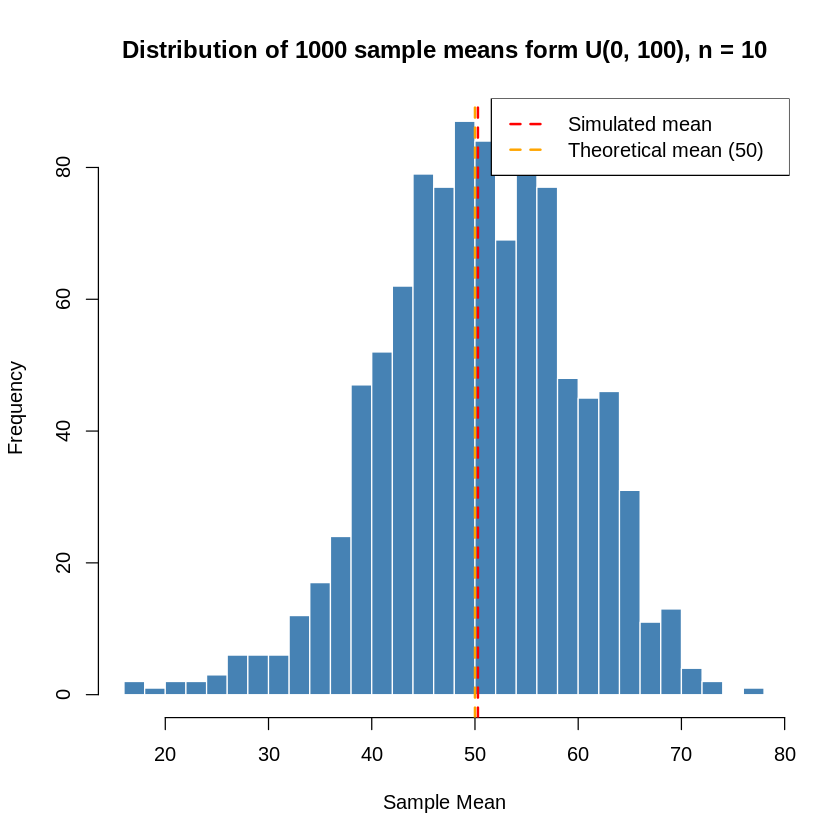

In [10]:
# Your Code Here
m <- 1000
n <- 10
simulated_sample_means <- replicate(m, uniform.sample.mean(n))
cat("E[sample mean]   =", mean(simulated_sample_means), "\n")
cat("Var(sample mean) =", var(simulated_sample_means),  "\n")

hist(simulated_sample_means,
breaks = 30,
main = "Distribution of 1000 sample means form U(0, 100), n = 10",
xlab = "Sample Mean",
col = "steelblue",
border = "white")

abline(v = mean(simulated_sample_means), col = "red", lwd = 2, lty = 2)
abline(v = 50, col = "orange", lwd = 2, lty = 2)

legend("topright",
legend = c("Simulated mean", "Theoretical mean (50)"),
col = c("red", "orange"),
lwd = 2, lty = 2)

<hr>

# Problem 2

Let $X$ be a random variable for the face value of a fair $d$-sided die after a single roll. $X$ follows a discrete uniform distribution of the form $\textrm{unif}\{1,d\}$. Below is the mean and variance of $\textrm{unif}\{1,d\}$.

$$ E[X] = \dfrac{1+d}{2} \qquad Var(X) = \dfrac{(d- 1 + 1)^2 - 1}{12}$$

**a)** Let $\bar{X}_n$ be the random variable for the mean of $n$ die rolls. Based on the Central Limit Theorem, what distribution does $\bar{X}_n$ follow when $d=6$?

**b)** Generate $n=1000$ die values, with $d=6$. Calculate the running average of your die rolls. In other words, create an array $r$ such that:

$$ r[j] = \sum_{i=1}^j \dfrac{X_i}{j} $$

Finally, plot your running average per the number of iterations. What do you notice?

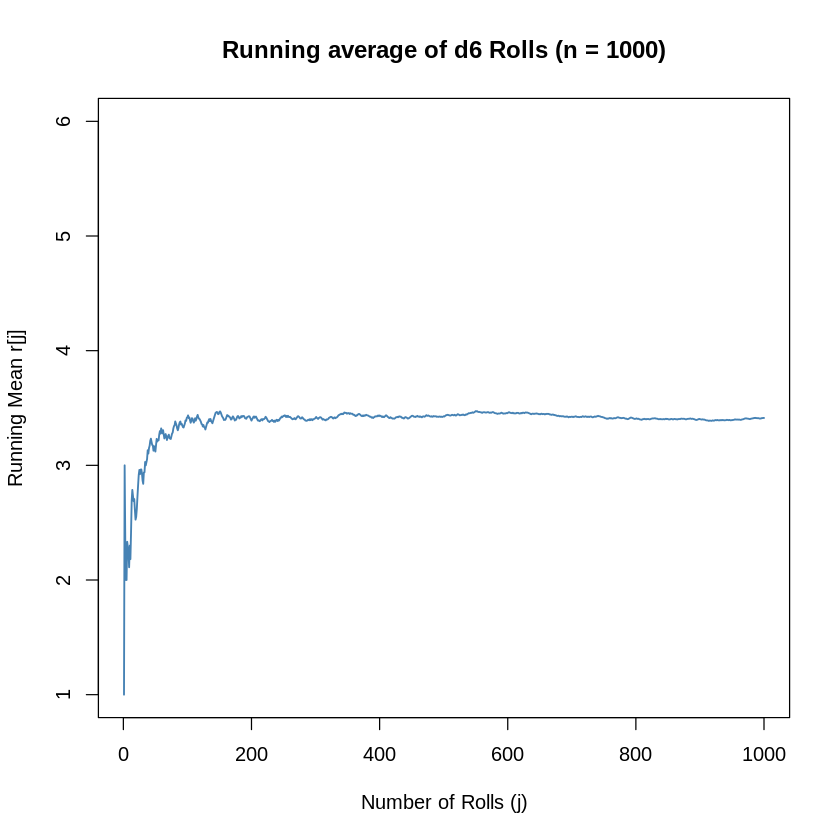

In [13]:
# Your code here.
set.seed(42)
n <- 1000
d <- 6

rolls <- sample(1:d, size = n, replace = TRUE)
# r[j] = (1/j)* sum_{i=1}^{j} X_i
r <- cumsum(rolls) / seq_along(rolls)

plot(1:n, r,
type = "l", col = "steelblue", lwd = 1.5, 
main = "Running average of d6 Rolls (n = 1000)",
xlab = "Number of Rolls (j)",
ylab = "Running Mean r[j]",
ylim = c(1, 6))